# **Beyond the Diagnosis: A Demographic and Behavioral Profiling of Autism Spectrum Traits**

## Problem Statement

Our objective is to analyze screening data to uncover hidden patterns, demographic disparities, and behavioral clusters within the autism spectrum. Through statistical analysis and interactive data storytelling, we intend to map how various traits—such as eye contact, social mimicking, and imagination—differ across key demographic factors including gender, age groups, and medical histories (e.g., jaundice or family genetics). This approach will provide a more nuanced understanding of how ASD manifests across diverse populations.

### Column Descriptions

| Column Name| Description |
|:-----------|:------------|
| A1         |Do you make eye contact when someone calls your name? ["No","Yes"]|
| A2         |Is it easy for others to get eye contact with you? ["No","Yes"]|
| A3         |Do you point to request something you want? ["No","Yes"]|
| A4         |Do you point to share something interesting with others? ["No","Yes"]|
| A5         |Do you engage in imaginative activities or role-play? ["No","Yes"]|
| A6         |Do you follow others' gaze to see what they're looking at? ["No","Yes"]|
| A7         |Do you try to comfort someone who appears upset? ["No","Yes"]|
| A8         |Would you describe your communication style as typical? ["No","Yes"]|
| A9         |Do you use common gestures (like waving goodbye)? ["No","Yes"]|
| A10        |Do you sometimes stare into space without focus? ["No","Yes"]|
| Age        |Age of the individual in years|
| Sex        |Gender of the individual ["Male","Female"]|
| Jaundice   |Indicates if the individual was born with jaundice [1 = "Yes",0 = "No"]|
| Family_ASD |Indicates if an immediate family member has ASD (1 = "Yes", 0 = "No")|
| Class      |The screening outcome (Yes = Potential ASD, No = Typical)|
| Age_Group   |Categorization of the individual's age["Child","Adolescent","Adult"]|
| High_Risk_Background |A derived binary indicator of risk based on history|
| Risk_Overlap |Describes the combination of background risk factors (e.g., Jaundice, Family ASD)|
| Social_Interaction_Score |This score is the sum of A1 (Eye contact when called), A2 (Easy for others to get eye contact), and A6 (Follow others' gaze).|
| Communication_Deficit_Score |This score is derived from the inverse of A3 (Point to request), A4 (Point to share), and A9 (Use common gestures). The inverse is calculated as (1 - A_value), meaning if a trait is present (1), its inverse is 0, indicating no deficit, and if absent (0), its inverse is 1, indicating a potential deficit|
| Behavioral_Atypicality_Score |This score combines the inverse of A5 (Engage in imaginative activities), A7 (Comfort upset person), A8 (Typical communication style), and the direct score of A10 (Stare into space). The inverse calculation (1 - A_value) applies to A5, A7, and A8|
| Total_Atypical_Trait_Burden |The total score (sum of A1 through A10)|
| Empathy_Imagination_Profile |A category based on empathy and imagination traits|
| Behavioral_Archetype |A qualitative profile representing the individual's behavior|
| Late_Diagnosis_Flag |Flag for individuals diagnosed/screened at an older age for their group|
| Masking_Proxy_Flag |Indicator suggesting potential masking of symptoms|

### Installation of Libraries

In [ ]:
pip install pandas numpy matplotlib seaborn missingno upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=08a4d9073f4f553b6fe2dc9c0afa58dc0d452d1448eb35978503147b9b985459
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


### Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno #specialized library to visually check for missing data.
from upsetplot import from_memberships, plot as upset_plot #UpSet plots visualize set intersections (an alternative to Venn diagrams for many sets).

sns.set_theme(style="whitegrid", palette="muted")

### Ingestion of dataset

In [ ]:
df = pd.read_csv('/content/Autism_Screening_Data_Combined.csv')
df.head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES
5,0,1,1,1,0,1,1,0,1,0,14,m,no,no,NO
6,1,0,0,0,1,0,0,1,0,1,14,f,no,no,NO
7,1,0,0,0,1,0,0,1,0,1,12,m,no,no,NO
8,1,0,0,0,1,0,0,1,0,1,15,f,no,no,NO
9,0,1,1,1,0,1,1,0,1,0,12,f,no,no,NO


In [ ]:
# Indexing rows from 1
df = df.reset_index(drop=True)
df.index = df.index + 1

In [ ]:
df.index.name = 'Case_Number'
display(df.head())

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
Case_Number,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
2,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
3,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
4,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
5,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


### Inspection of the data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6075 entries, 1 to 6075
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          6075 non-null   int64 
 1   A2          6075 non-null   int64 
 2   A3          6075 non-null   int64 
 3   A4          6075 non-null   int64 
 4   A5          6075 non-null   int64 
 5   A6          6075 non-null   int64 
 6   A7          6075 non-null   int64 
 7   A8          6075 non-null   int64 
 8   A9          6075 non-null   int64 
 9   A10         6075 non-null   int64 
 10  Age         6075 non-null   int64 
 11  Sex         6075 non-null   object
 12  Jaundice    6075 non-null   object
 13  Family_ASD  6075 non-null   object
 14  Class       6075 non-null   object
dtypes: int64(11), object(4)
memory usage: 712.0+ KB


### Looking for chunks of missing data

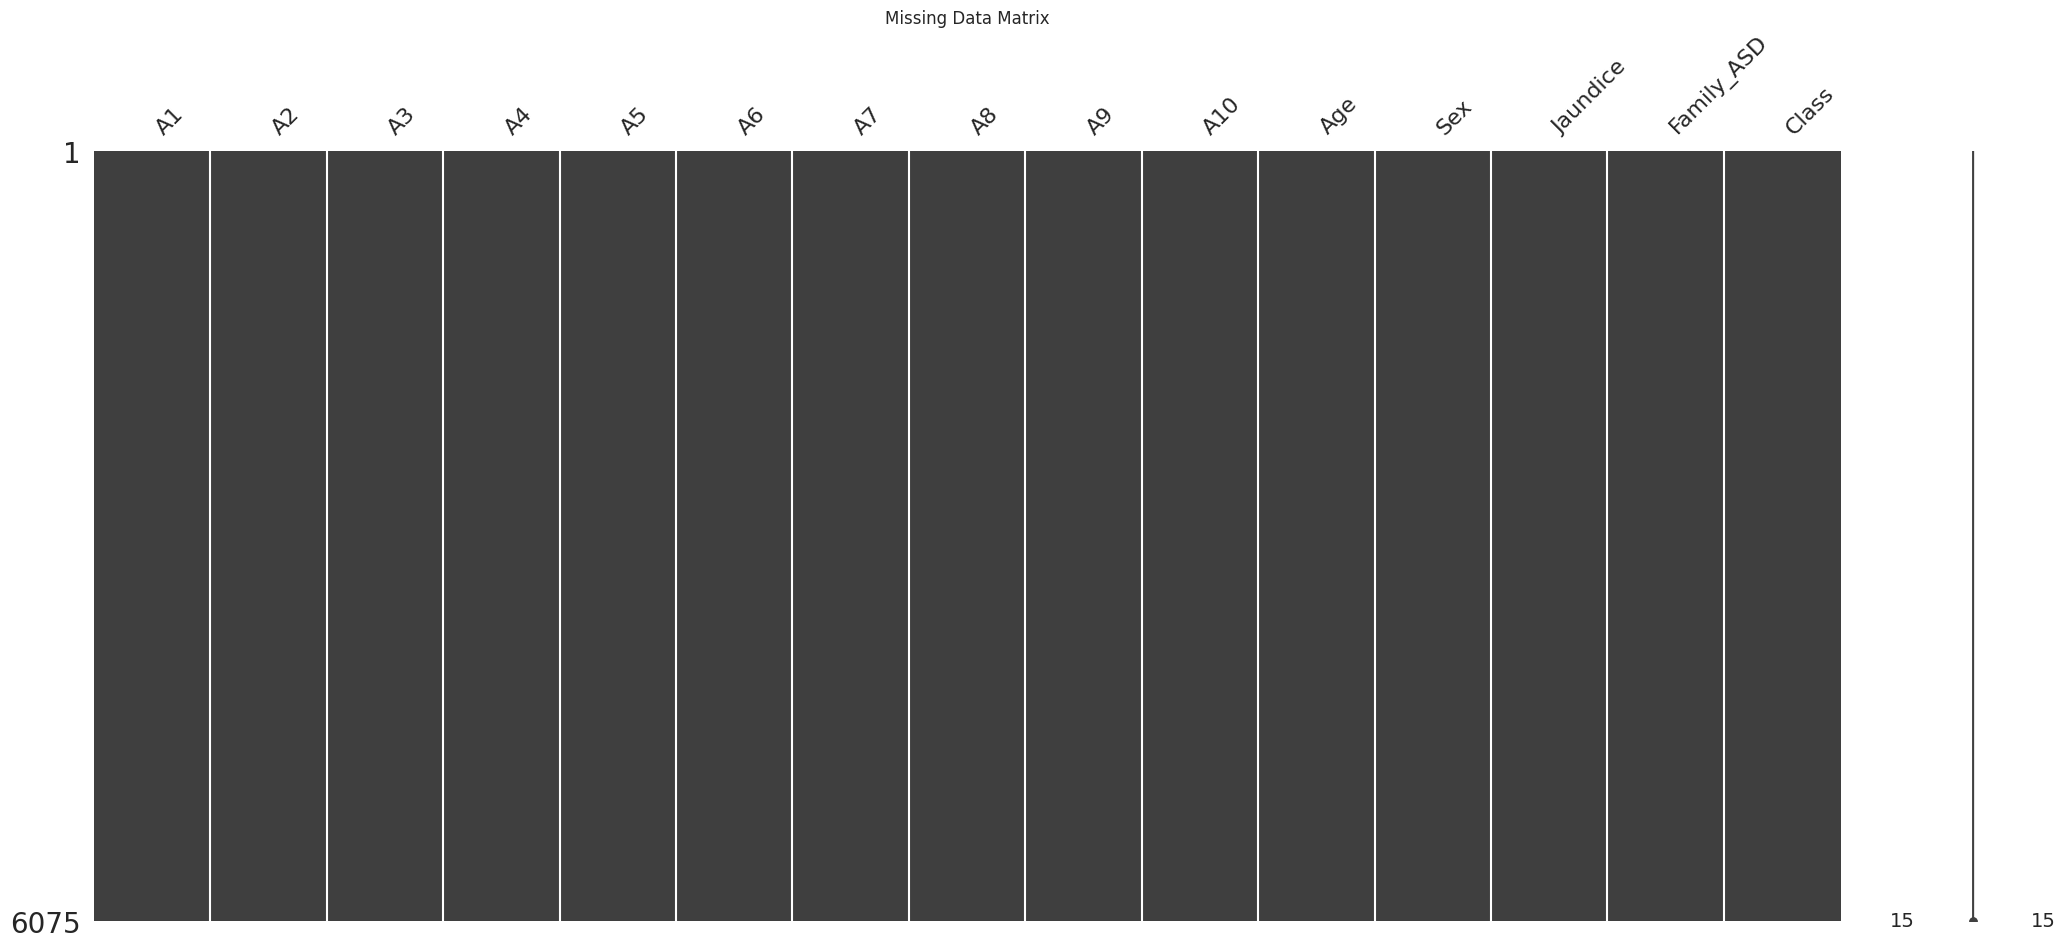

In [ ]:
msno.matrix(df)
plt.title("Missing Data Matrix")
plt.show()

In [ ]:
display(df.describe())

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age
count,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000,6075.000000
mean,0.693169,0.485103,0.537449,0.547490,0.543868,0.443128,0.497942,0.538436,0.429794,0.599835,19.838025
std,0.461217,0.499819,0.498637,0.497781,0.498113,0.496796,0.500037,0.498562,0.495087,0.489972,14.934246
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
50%,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,19.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,80.000000


In [ ]:
df['Age'].describe()

,Age
count,6075.000000
mean,19.838025
std,14.934246
min,1.000000
25%,5.000000
50%,19.000000
75%,30.000000
max,80.000000


**Key Insights from Initial Inspection:**
1.  **No Missing Values**: All columns have 6075 non-null entries, indicating a complete dataset with no missing values.
2.  **Binary Features (A1-A10)**: The `describe()` output, particularly the min (0) and max (1) values for columns `A1` to `A10`, confirms that these are strictly binary (0 or 1) as expected for Yes/No questions.
3.  **Age Distribution**: The `Age` column shows a wide range (min 4, max 80) with a mean of approximately 19.84 and a median of 19. The standard deviation of 14.93 indicates a significant spread in ages across the dataset.


### Data Type & Consistency Check

In [ ]:
# 1. Validate A1 to A10 are strictly binary
for col in ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']:
    unique_values = df[col].unique()
    if not all(val in [0, 1] for val in unique_values):
        print(f"Warning: Column '{col}' contains non-binary values: {unique_values}")
    else:
        print(f"Column '{col}' is strictly binary (0 or 1).")


Column 'A1' is strictly binary (0 or 1).
Column 'A2' is strictly binary (0 or 1).
Column 'A3' is strictly binary (0 or 1).
Column 'A4' is strictly binary (0 or 1).
Column 'A5' is strictly binary (0 or 1).
Column 'A6' is strictly binary (0 or 1).
Column 'A7' is strictly binary (0 or 1).
Column 'A8' is strictly binary (0 or 1).
Column 'A9' is strictly binary (0 or 1).
Column 'A10' is strictly binary (0 or 1).


In [ ]:
# 2. Map 'Sex' to standardized strings ('Male', 'Female')
sex_mapping = {'m': 'Male', 'f': 'Female'}
df['Sex'] = df['Sex'].replace(sex_mapping)

print("Unique values in 'Sex' after standardization:")
display(df['Sex'].unique())


Unique values in 'Sex' after standardization:


array(['Male', 'Female'], dtype=object)

### Performing Standardization to eliminate phantom categories

In [ ]:
# 3. Convert 'Jaundice', 'Family_ASD', and 'Class' to 'Yes'/'No' categorical formats
# Convert all to lowercase first to handle 'NO' and 'no' consistently

df['Jaundice'] = df['Jaundice'].str.lower().str.strip().replace({'yes': 'Yes', 'no': 'No'})
df['Family_ASD'] = df['Family_ASD'].str.lower().str.strip().replace({'yes': 'Yes', 'no': 'No'})
df['Class'] = df['Class'].str.lower().str.strip().replace({'yes': 'Yes', 'no': 'No'})

print("Unique values in 'Jaundice' after standardization:")
display(df['Jaundice'].unique())
print("Unique values in 'Family_ASD' after standardization:")
display(df['Family_ASD'].unique())
print("Unique values in 'Class' after standardization:")
display(df['Class'].unique())

Unique values in 'Jaundice' after standardization:


array(['No', 'Yes'], dtype=object)

Unique values in 'Family_ASD' after standardization:


array(['No', 'Yes'], dtype=object)

Unique values in 'Class' after standardization:


array(['No', 'Yes'], dtype=object)

### Outlier treatment for Age

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
print(IQR)
upper_bound = Q3 + 1.5 * IQR

print(f"First Quartile (Q1) for Age: {Q1:.0f}")
print(f"Third Quartile (Q3) for Age: {Q3:.0f}")
print(f"Interquartile Range (IQR) for Age: {IQR:.0f}")

5.0
30.0
25.0
First Quartile (Q1) for Age: 5
Third Quartile (Q3) for Age: 30
Interquartile Range (IQR) for Age: 25


In [ ]:
# Cap extreme age outliers at the upper bound (Winsorization)
df['Age'] = np.where(df['Age'] > upper_bound, upper_bound, df['Age'])

In [ ]:
# Rounds the numbers and safely converts to integer, ignoring NaNs
df['Age'] = df['Age'].round().astype('Int64')

Text(0.5, 1.0, 'Box Plot of Age')

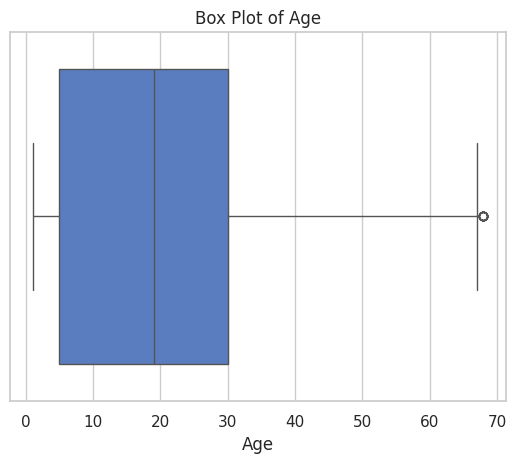

In [ ]:
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')

Text(0.5, 1.0, 'Histogram of Age')

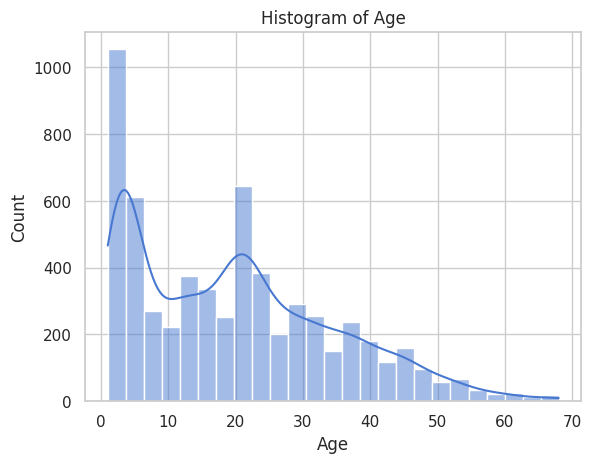

In [ ]:
sns.histplot(df['Age'], kde=True)
plt.title('Histogram of Age')

### Count of categorical data

In [ ]:
print("\nDistribution of 'Sex':")
display(df['Sex'].value_counts())

print("\nDistribution of 'Jaundice':")
display(df['Jaundice'].value_counts())

print("\nDistribution of 'Family_ASD':")
display(df['Family_ASD'].value_counts())

print("\nDistribution of 'Class' (ASD diagnosis):")
display(df['Class'].value_counts())



Distribution of 'Sex':


,count
Sex,
Male,3508
Female,2567



Distribution of 'Jaundice':


,count
Jaundice,
No,5030
Yes,1045



Distribution of 'Family_ASD':


,count
Family_ASD,
No,4953
Yes,1122



Distribution of 'Class' (ASD diagnosis):


,count
Class,
No,4271
Yes,1804


### Printing the updated dataframe

In [ ]:
df.head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class
Case_Number,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,15,Male,No,No,No
2,0,1,1,1,0,1,1,0,1,0,15,Male,No,No,No
3,1,1,1,0,1,1,1,1,1,1,15,Female,No,Yes,Yes
4,1,1,1,1,1,1,1,1,0,0,16,Female,No,No,Yes
5,1,1,1,1,1,1,1,1,1,1,15,Female,No,No,Yes
6,0,1,1,1,0,1,1,0,1,0,14,Male,No,No,No
7,1,0,0,0,1,0,0,1,0,1,14,Female,No,No,No
8,1,0,0,0,1,0,0,1,0,1,12,Male,No,No,No
9,1,0,0,0,1,0,0,1,0,1,15,Female,No,No,No


# The Gender Presentation Gap

### Do males have a higher percentage of positive diagnoses than females?

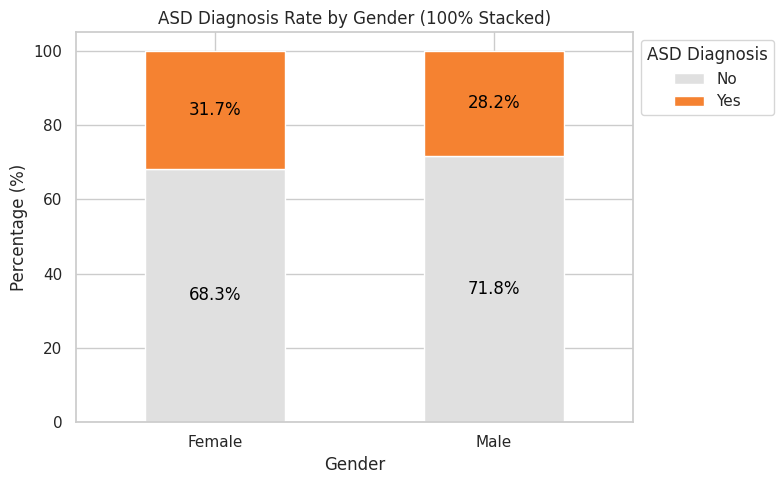

In [ ]:
# Calculate the percentage of diagnosis grouped by Gender
crosstab_gender = pd.crosstab(df['Sex'], df['Class'], normalize='index') * 100

ax = crosstab_gender.plot(kind='bar', stacked=True, color=['#e0e0e0', '#F58231'], figsize=(8, 5))
plt.title('ASD Diagnosis Rate by Gender (100% Stacked)')
plt.ylabel('Percentage (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)

# --- NEW CODE: Add labels to the center of each stacked segment ---
for container in ax.containers:
    # fmt='%.1f%%' formats the number to 1 decimal place and adds a '%' sign
    # label_type='center' puts the text in the middle of the colored block
    ax.bar_label(container, fmt='%.1f%%', label_type='center', color='black')

plt.legend(title='ASD Diagnosis', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('month1_gender_gap_stacked.png', dpi=300)
plt.show()

# Age Distribution & Diagnostic Density

### Checking if intervention was taken during childhood or adulthood

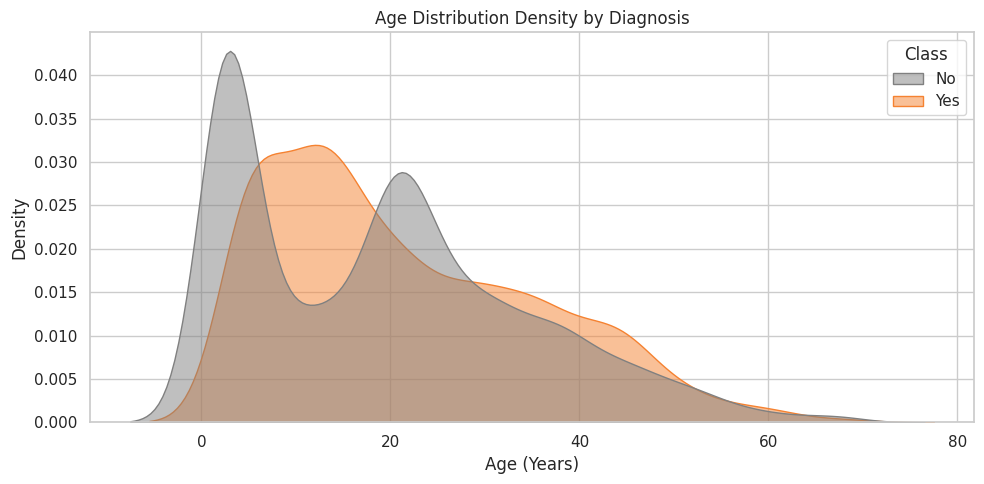

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Age', hue='Class', fill=True, common_norm=False,palette={'No': 'gray', 'Yes': '#F58231'}, alpha=0.5)
plt.title('Age Distribution Density by Diagnosis')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig('month1_age_density_kde.png', dpi=300)
plt.show()

# Medical Risk Factor Proportions
Establishing the exact baseline prevalence of the two main medical risk factors

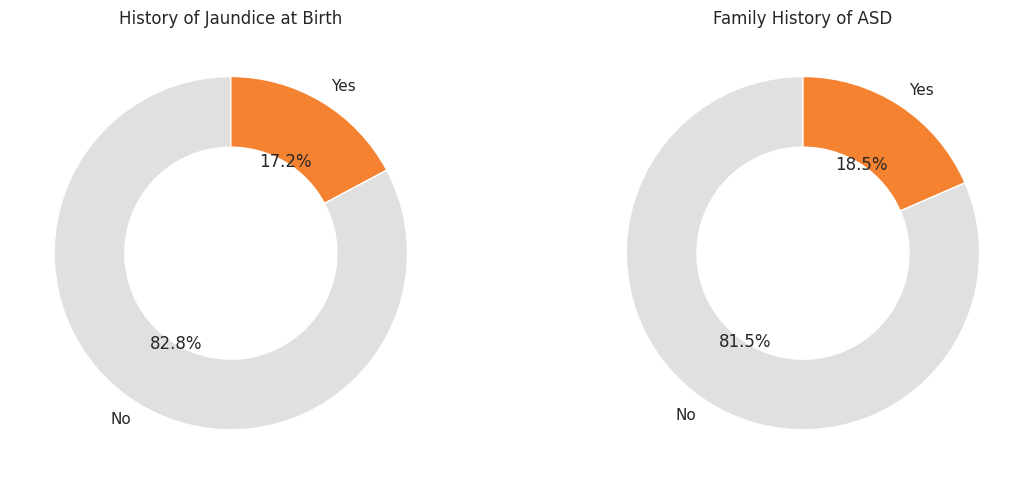

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Donut 1: History of Jaundice
jaundice_counts = df['Jaundice'].value_counts()
ax1.pie(jaundice_counts, labels=jaundice_counts.index, autopct='%1.1f%%',
        colors=['#e0e0e0', '#F58231'], startangle=90, wedgeprops=dict(width=0.4))
ax1.set_title('History of Jaundice at Birth')

# Donut 2: Family History of ASD
family_counts = df['Family_ASD'].value_counts()
ax2.pie(family_counts, labels=family_counts.index, autopct='%1.1f%%',
        colors=['#e0e0e0', '#F58231'], startangle=90, wedgeprops=dict(width=0.4))
ax2.set_title('Family History of ASD')

plt.tight_layout()
plt.savefig('month1_risk_factors_donuts.png', dpi=300)

# Demographic Risk Cross-Tabulation
Who is at the highest risk? A male with a family history, or a female with a family history?

/tmp/ipykernel_5119/3910019207.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Class'] = df['Class'].replace({'Yes': 1, 'No': 0}).astype(int)


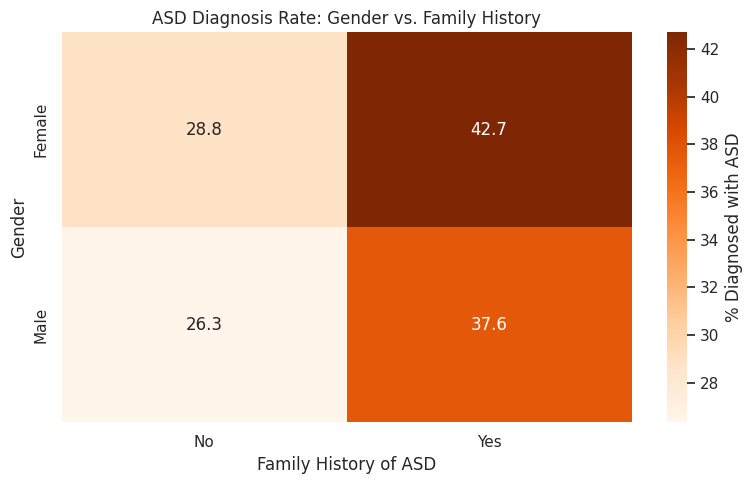

In [ ]:
# Calculate the mean of 'Class' (which is 1 for Yes, 0 for No) to get the percentage diagnosed
# Ensure 'Class' is numerical before calculating the mean
df['Class'] = df['Class'].replace({'Yes': 1, 'No': 0}).astype(int)
heatmap_data = df.groupby(['Sex', 'Family_ASD'])['Class'].mean().unstack() * 100

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="Oranges", cbar_kws={'label': '% Diagnosed with ASD'})
plt.title('ASD Diagnosis Rate: Gender vs. Family History')
plt.xlabel('Family History of ASD')
plt.ylabel('Gender')
plt.tight_layout()
plt.savefig('month1_demographic_heatmap.png', dpi=300)
plt.show()

# **Foundational Feature Engineering**

# Age Grouping

To facilitate a more granular analysis of how ASD traits manifest across different developmental stages, a new categorical feature called `Age_Group` was engineered. This feature categorizes individuals into 'Child', 'Adolescent', and 'Adult' based on their 'Age'.

**Creation Process:**

The `Age_Group` was created using the `pd.cut()` function, which bins the numerical 'Age' column into predefined intervals. The following bins and labels were used:
-   **Children:** Ages 0 to 12 years
-   **Adolescents:** Ages 13 to 18 years
-   **Adults:** Ages 19 to 81 years (considering the maximum age in the dataset is 80).

**Rationale:**

Categorizing age into these groups allows for a more insightful analysis of behavioral and demographic patterns. ASD presentations can vary significantly with age, and this grouping helps in identifying specific challenges or characteristics prevalent in different life stages. For instance, certain social or communication traits might be more pronounced or interpreted differently in a child compared to an adult.


This distribution indicates a substantial representation across all major developmental stages, allowing for comprehensive comparative analysis.

In [ ]:
# Define age bins and labels for 'Child', 'Adolescent', 'Adult'
age_bins = [0, 12, 18, 81] # Age up to 12 as Child, 13-18 as Adolescent, 19+ as Adult (max age is 80)
age_labels = ['Child', 'Adolescent', 'Adult']

df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

print("Distribution of 'Age_Group':")
display(df['Age_Group'].value_counts())


Distribution of 'Age_Group':


,count
Age_Group,
Adult,3094
Child,2303
Adolescent,678


# Risk Profiling Flags

### High_Risk_Background Feature Explanation

The `High_Risk_Background` feature is a new binary flag (0 or 1) engineered to identify individuals who present with a combination of two specific risk factors: a history of `Jaundice` and a `Family_ASD` history.

This feature is created based on the following condition:
- If an individual has both `Jaundice` = 'Yes' and `Family_ASD` = 'Yes', then `High_Risk_Background` is set to `1`.
- Otherwise, `High_Risk_Background` is set to `0`.

The rationale behind this feature is to create a composite indicator for a potentially elevated background risk of ASD. By combining these two medical history factors, we can investigate if the presence of both correlates more strongly with ASD traits or diagnosis than each factor individually. This provides a more nuanced approach to risk profiling within the dataset.

In [ ]:
# Create a binary High_Risk_Background feature
df['High_Risk_Background'] = ((df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'Yes')).astype(int)

print("Distribution of 'High_Risk_Background':")
display(df['High_Risk_Background'].value_counts())

print("Displaying first 10 rows with new features:")
display(df.head(10))


Distribution of 'High_Risk_Background':


,count
High_Risk_Background,
0,5808
1,267


Displaying first 10 rows with new features:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Class,Age_Group,High_Risk_Background
Case_Number,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,15,Male,No,No,0,Adolescent,0
2,0,1,1,1,0,1,1,0,1,0,15,Male,No,No,0,Adolescent,0
3,1,1,1,0,1,1,1,1,1,1,15,Female,No,Yes,1,Adolescent,0
4,1,1,1,1,1,1,1,1,0,0,16,Female,No,No,1,Adolescent,0
5,1,1,1,1,1,1,1,1,1,1,15,Female,No,No,1,Adolescent,0
6,0,1,1,1,0,1,1,0,1,0,14,Male,No,No,0,Adolescent,0
7,1,0,0,0,1,0,0,1,0,1,14,Female,No,No,0,Adolescent,0
8,1,0,0,0,1,0,0,1,0,1,12,Male,No,No,0,Child,0
9,1,0,0,0,1,0,0,1,0,1,15,Female,No,No,0,Adolescent,0


/tmp/ipykernel_5119/1252175600.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


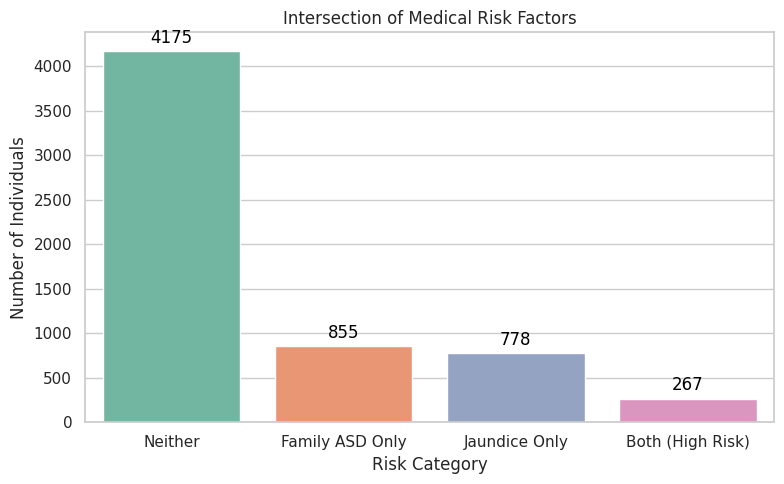

In [ ]:
plt.figure(figsize=(8, 5))

# Check for the actual column names you used earlier
if 'Jaundice' in df.columns and 'Family_ASD' in df.columns:
    conditions = [
        (df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'Yes'),
        (df['Jaundice'] == 'Yes') & (df['Family_ASD'] == 'No'),
        (df['Jaundice'] == 'No') & (df['Family_ASD'] == 'Yes'),
        (df['Jaundice'] == 'No') & (df['Family_ASD'] == 'No')
    ]
    choices = ['Both (High Risk)', 'Jaundice Only', 'Family ASD Only', 'Neither']

    # Create the new overlap column
    df['Risk_Overlap'] = np.select(conditions, choices, default='Unknown')

    # Assign the plot to 'ax' so we can modify it
    ax = sns.countplot(
        data=df,
        x='Risk_Overlap',
        order=['Neither', 'Family ASD Only', 'Jaundice Only', 'Both (High Risk)'],
        palette='Set2'
    )

    # --- NEW CODE: Add data labels to the top of each bar ---
    for container in ax.containers:
        # padding=3 adds a little breathing room between the bar and the number
        ax.bar_label(container, padding=3, color='black')

    plt.title('Intersection of Medical Risk Factors')
    plt.ylabel('Number of Individuals')
    plt.xlabel('Risk Category')
    plt.tight_layout()
    plt.savefig('risk_overlap.png', dpi=300)
    plt.show()

else:
    print("ERROR: Could not find 'Jaundice' or 'Family_ASD' in the dataset.")

# Composite Scores
### Creating composite behavioral metrics to add analytical depth

To enhance the analytical depth of our dataset, we have created several composite scores by aggregating related binary behavioral traits. These scores move beyond individual 'Yes'/'No' responses to provide a more holistic view of different aspects of the autism spectrum traits. These additions are reflected in a conceptual 'Data Dictionary 2.0'.

1.  **Social_Interaction_Score (Range: 0-3)**:
    *   **Calculation**: This score is the sum of `A1` (Eye contact when called), `A2` (Easy for others to get eye contact), and `A6` (Follow others' gaze).
    *   **Rationale**: A higher score indicates a greater presence of social interaction behaviors. This composite score aims to quantify an individual's engagement in fundamental social interaction cues, which are often impacted in ASD.

2.  **Communication_Deficit_Score (Range: 0-3)**:
    *   **Calculation**: This score is derived from the inverse of `A3` (Point to request), `A4` (Point to share), and `A9` (Use common gestures). The inverse is calculated as `(1 - A_value)`, meaning if a trait is present (1), its inverse is 0, indicating no deficit, and if absent (0), its inverse is 1, indicating a potential deficit.
    *   **Rationale**: A higher score here suggests a greater deficit in typical communication behaviors. This score attempts to capture the challenges individuals might face in using conventional non-verbal communication methods.

3.  **Behavioral_Atypicality_Score (Range: 0-4)**:
    *   **Calculation**: This score combines the inverse of `A5` (Engage in imaginative activities), `A7` (Comfort upset person), `A8` (Typical communication style), and the direct score of `A10` (Stare into space). The inverse calculation `(1 - A_value)` applies to A5, A7, and A8.
    *   **Rationale**: This score aims to quantify the presence of behaviors often considered atypical or challenging within the context of ASD. A higher score implies more pronounced atypical behavioral patterns.

These composite scores offer a richer, more continuous representation of complex behavioral dimensions than their individual binary components, allowing for more nuanced analysis of trait presentation across different demographic groups. For reference, the first 20 rows of the DataFrame, including these newly engineered scores, have been displayed in the previous output.

In [ ]:
# Social Interaction Score (0-3): Sum of A1, A2, and A6.
df['Social_Interaction_Score'] = df['A1'] + df['A2'] + df['A6']

# Communication Deficit Score (0-3): Sum of inverse A3, inverse A4, and inverse A9.
# Reversing the scale: 1 - A_value (if A_value=1, inverse is 0; if A_value=0, inverse is 1)
df['Communication_Deficit_Score'] = (1 - df['A3']) + (1 - df['A4']) + (1 - df['A9'])

# Behavioral Atypicality Score (0-4): Sum of inverse A5, inverse A7, inverse A8, and A10.
df['Behavioral_Atypicality_Score'] = (1 - df['A5']) + (1 - df['A7']) + (1 - df['A8']) + df['A10']

print("New composite scores added to the DataFrame. Displaying the first 10 rows with new scores:")
display(df.head(15))

New composite scores added to the DataFrame. Displaying the first 10 rows with new scores:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Sex,Jaundice,Family_ASD,Class,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,Male,No,No,0,Adolescent,0,Neither,2,2,1
2,0,1,1,1,0,1,1,0,1,0,...,Male,No,No,0,Adolescent,0,Neither,2,0,2
3,1,1,1,0,1,1,1,1,1,1,...,Female,No,Yes,1,Adolescent,0,Family ASD Only,3,1,1
4,1,1,1,1,1,1,1,1,0,0,...,Female,No,No,1,Adolescent,0,Neither,3,1,0
5,1,1,1,1,1,1,1,1,1,1,...,Female,No,No,1,Adolescent,0,Neither,3,0,1
6,0,1,1,1,0,1,1,0,1,0,...,Male,No,No,0,Adolescent,0,Neither,2,0,2
7,1,0,0,0,1,0,0,1,0,1,...,Female,No,No,0,Adolescent,0,Neither,1,3,2
8,1,0,0,0,1,0,0,1,0,1,...,Male,No,No,0,Child,0,Neither,1,3,2
9,1,0,0,0,1,0,0,1,0,1,...,Female,No,No,0,Adolescent,0,Neither,1,3,2


### Cross verifying key demographics with the columns existing in the dataframe

In [ ]:
print("Normalized distribution of 'Sex':")
display(df['Sex'].value_counts(normalize=True))

print("Normalized distribution of 'Jaundice':")
display(df['Jaundice'].value_counts(normalize=True))

print("Normalized distribution of 'Family_ASD':")
display(df['Family_ASD'].value_counts(normalize=True))

print("Normalized distribution of 'Class' (ASD diagnosis):")
display(df['Class'].value_counts(normalize=True))

print("Normalized distribution of 'Age_Group':")
display(df['Age_Group'].value_counts(normalize=True))

print("Normalized distribution of 'High_Risk_Background':")
display(df['High_Risk_Background'].value_counts(normalize=True))

Normalized distribution of 'Sex':


,proportion
Sex,
Male,0.577449
Female,0.422551


Normalized distribution of 'Jaundice':


,proportion
Jaundice,
No,0.827984
Yes,0.172016


Normalized distribution of 'Family_ASD':


...

,proportion
Class,
0,0.703045
1,0.296955


Normalized distribution of 'Age_Group':


,proportion
Age_Group,
Adult,0.509300
Child,0.379095
Adolescent,0.111605


Normalized distribution of 'High_Risk_Background':


,proportion
High_Risk_Background,
0,0.956049
1,0.043951


# Dimensionality Expansion and Feature Engineering

## Medical Risk Factor Profiling
Objective: Isolate specific medical and genetic backgrounds to enable cumulative risk assessment.

### Standardize Core Risk Flags

In [ ]:
# Convert Jaundice and Family_ASD to Binary

df['Jaundice'] = df['Jaundice'].replace({'Yes': 1, 'No': 0}).astype(int)
df['Family_ASD'] = df['Family_ASD'].replace({'Yes': 1, 'No': 0}).astype(int)

print("Distribution of 'Jaundice' after conversion:")
display(df['Jaundice'].value_counts())

print("Distribution of 'Family_ASD' after conversion:")
display(df['Family_ASD'].value_counts())

print("First few rows of the updated DataFrame:")
display(df.head())

Distribution of 'Jaundice' after conversion:


/tmp/ipykernel_5119/1124707122.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Jaundice'] = df['Jaundice'].replace({'Yes': 1, 'No': 0}).astype(int)
/tmp/ipykernel_5119/1124707122.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Family_ASD'] = df['Family_ASD'].replace({'Yes': 1, 'No': 0}).astype(int)


,count
Jaundice,
0,5030
1,1045


Distribution of 'Family_ASD' after conversion:


,count
Family_ASD,
0,4953
1,1122


First few rows of the updated DataFrame:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Sex,Jaundice,Family_ASD,Class,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,Male,0,0,0,Adolescent,0,Neither,2,2,1
2,0,1,1,1,0,1,1,0,1,0,...,Male,0,0,0,Adolescent,0,Neither,2,0,2
3,1,1,1,0,1,1,1,1,1,1,...,Female,0,1,1,Adolescent,0,Family ASD Only,3,1,1
4,1,1,1,1,1,1,1,1,0,0,...,Female,0,0,1,Adolescent,0,Neither,3,1,0
5,1,1,1,1,1,1,1,1,1,1,...,Female,0,0,1,Adolescent,0,Neither,3,0,1


In [ ]:
pd.set_option('future.no_silent_downcasting', True)
df['Class'] = df['Class'].replace({'Yes': 1, 'No': 0}).astype(int)

print("Distribution of 'Class' after conversion:")
display(df['Class'].value_counts())

print("First few rows of the updated DataFrame:")
display(df.head())

Distribution of 'Class' after conversion:


,count
Class,
0,4271
1,1804


First few rows of the updated DataFrame:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Sex,Jaundice,Family_ASD,Class,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,Male,0,0,0,Adolescent,0,Neither,2,2,1
2,0,1,1,1,0,1,1,0,1,0,...,Male,0,0,0,Adolescent,0,Neither,2,0,2
3,1,1,1,0,1,1,1,1,1,1,...,Female,0,1,1,Adolescent,0,Family ASD Only,3,1,1
4,1,1,1,1,1,1,1,1,0,0,...,Female,0,0,1,Adolescent,0,Neither,3,1,0
5,1,1,1,1,1,1,1,1,1,1,...,Female,0,0,1,Adolescent,0,Neither,3,0,1


## Risk Segmentation Verification

In [ ]:
print("Verifying the segmentation based on 'High_Risk_background' column:")
display(df['High_Risk_Background'].value_counts())

low_risk_count = df['High_Risk_Background'].value_counts().get(0, 0)
high_risk_count = df['High_Risk_Background'].value_counts().get(1, 0)

print(f"Low-risk population: {low_risk_count} individuals")
print(f"High-risk population: {high_risk_count} individuals")

if low_risk_count == 5808 and high_risk_count == 267:
    print("\nSegmentation verified: The counts match the expected values.")
else:
    print("\nSegmentation mismatch: The counts do not match the expected values.")

Verifying the segmentation based on 'High_Risk_background' column:


,count
High_Risk_Background,
0,5808
1,267


Low-risk population: 5808 individuals
High-risk population: 267 individuals

Segmentation verified: The counts match the expected values.


# Macro-Level Trait Calculation

Objective: Build global severity metrics to evaluate the overall clinical picture of every patient.

### Calculate Total Atypical Trait Burden

In [ ]:
# Creating Total_Atypical_Trait_Burden
df['Total_Atypical_Trait_Burden'] = \
    (1 - df['A1']) + (1 - df['A2']) + (1 - df['A3']) + \
    (1 - df['A4']) + (1 - df['A5']) + (1 - df['A6']) + \
    (1 - df['A7']) + (1 - df['A8']) + (1 - df['A9']) + \
    df['A10']

# Ensure 'Class' column is 'Yes'/'No' strings for the palette in the next cell
df['Class'] = df['Class'].replace({1: 'Yes', 0: 'No'})

print("Distribution of 'Total_Atypical_Trait_Burden':")
display(df['Total_Atypical_Trait_Burden'].value_counts().sort_index())

print("First few rows with 'Total_Atypical_Trait_Burden':")
display(df.head())

Distribution of 'Total_Atypical_Trait_Burden':


,count
Total_Atypical_Trait_Burden,
0,51
1,384
2,644
3,775
4,882
5,835
6,833
7,813
8,510


First few rows with 'Total_Atypical_Trait_Burden':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Jaundice,Family_ASD,Class,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Total_Atypical_Trait_Burden
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,0,0,No,Adolescent,0,Neither,2,2,1,4
2,0,1,1,1,0,1,1,0,1,0,...,0,0,No,Adolescent,0,Neither,2,0,2,3
3,1,1,1,0,1,1,1,1,1,1,...,0,1,Yes,Adolescent,0,Family ASD Only,3,1,1,2
4,1,1,1,1,1,1,1,1,0,0,...,0,0,Yes,Adolescent,0,Neither,3,1,0,1
5,1,1,1,1,1,1,1,1,1,1,...,0,0,Yes,Adolescent,0,Neither,3,0,1,1


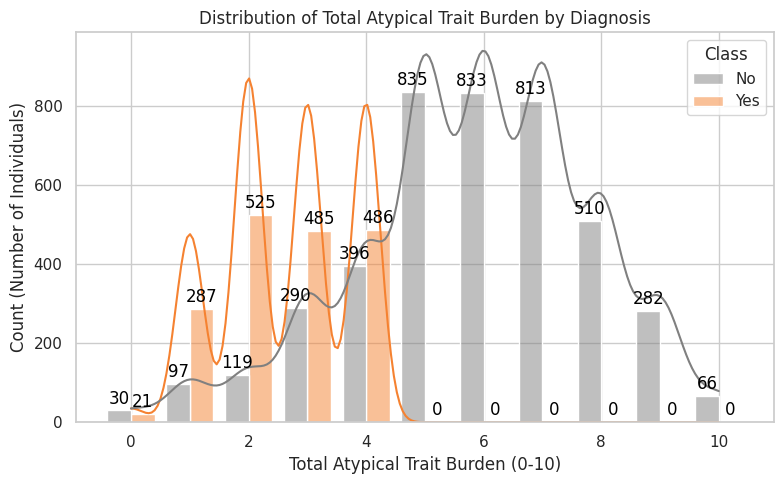

In [ ]:
plt.figure(figsize=(8, 5))

# Using the correct capitalization for 'Class'
if 'Total_Atypical_Trait_Burden' in df.columns and 'Class' in df.columns:

    # Switch to histplot to allow for exact count bars, but keep the KDE curve!
    ax = sns.histplot(
        data=df,
        x='Total_Atypical_Trait_Burden',
        hue='Class',            # Fixed to capital 'C'
        multiple='dodge',       # Puts the 'Yes' and 'No' bars side-by-side for comparison
        discrete=True,          # Ensures bars align perfectly with whole numbers (0-10)
        shrink=0.8,             # Adds a slight gap between bar groups for cleaner visuals
        kde=True,               # Keeps the smoothed density line you originally wanted
        palette={'No': 'gray', 'Yes': '#F58231'} # Fixed to match your 'Yes'/'No' standardization
    )

    # Loop through the bars to add the actual values
    for container in ax.containers:
        # We check if the container is a bar (ignoring the KDE line)
        if hasattr(container, 'datavalues'):
            ax.bar_label(container, padding=2, color='black')

    plt.title('Distribution of Total Atypical Trait Burden by Diagnosis')
    plt.xlabel('Total Atypical Trait Burden (0-10)')
    plt.ylabel('Count (Number of Individuals)')
    plt.tight_layout()
    plt.savefig('trait_burden_hist.png', dpi=300)
    plt.show()

else:
    # Adding the else statement to catch silent failures!
    print("ERROR: Could not find the required columns.")
    print("Current columns:", df.columns.tolist())

### Empathy vs. Systemizing Contrast Flag

In [ ]:
def get_empathy_imagination_profile(row):
    # 'No' for A7 means 0 (struggles with empathy)
    # 'Yes' for A5 means 1 (engages in imagination)
    if row['A7'] == 0 and row['A5'] == 1:
        return 'Isolated Emotional Deficit'
    # 'No' for A7 means 0 (struggles with empathy)
    # 'No' for A5 means 0 (does not engage in imagination)
    elif row['A7'] == 0 and row['A5'] == 0:
        return 'Global Cognitive/Emotional Deficit'
    else:
        return 'Other' # All other combinations (e.g., A7=1, A5=1; A7=1, A5=0)

df['Empathy_Imagination_Profile'] = df.apply(get_empathy_imagination_profile, axis=1)

print("Distribution of 'Empathy_Imagination_Profile':")
display(df['Empathy_Imagination_Profile'].value_counts())

print("First few rows with 'Empathy_Imagination_Profile':")
display(df.head())

Distribution of 'Empathy_Imagination_Profile':


,count
Empathy_Imagination_Profile,
Other,3025
Global Cognitive/Emotional Deficit,1763
Isolated Emotional Deficit,1287


First few rows with 'Empathy_Imagination_Profile':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Family_ASD,Class,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Total_Atypical_Trait_Burden,Empathy_Imagination_Profile
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,0,No,Adolescent,0,Neither,2,2,1,4,Other
2,0,1,1,1,0,1,1,0,1,0,...,0,No,Adolescent,0,Neither,2,0,2,3,Other
3,1,1,1,0,1,1,1,1,1,1,...,1,Yes,Adolescent,0,Family ASD Only,3,1,1,2,Other
4,1,1,1,1,1,1,1,1,0,0,...,0,Yes,Adolescent,0,Neither,3,1,0,1,Other
5,1,1,1,1,1,1,1,1,1,1,...,0,Yes,Adolescent,0,Neither,3,0,1,1,Other


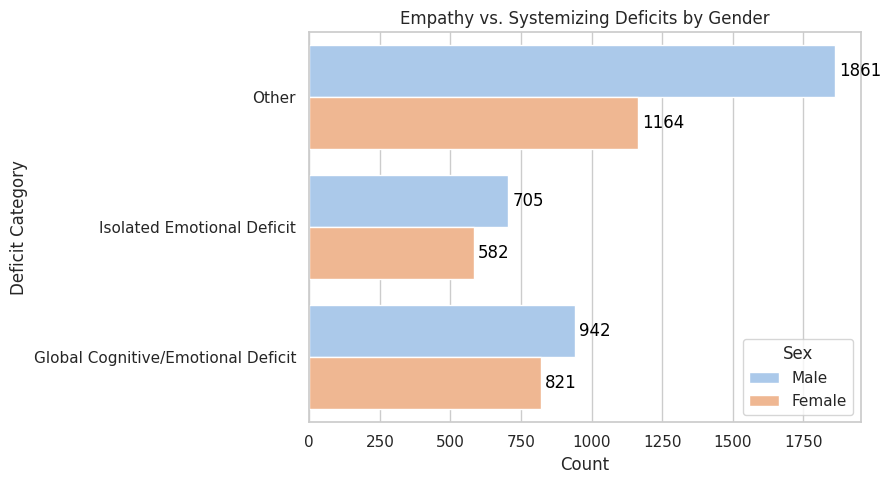

In [ ]:
plt.figure(figsize=(9, 5))

# Fixed the lowercase 'sex' to match your earlier dataset structure
if 'Empathy_Imagination_Profile' in df.columns and 'Sex' in df.columns:

    # Assign the plot to 'ax'
    ax = sns.countplot(
        data=df,
        y='Empathy_Imagination_Profile',
        hue='Sex',
        palette='pastel'
    )

    # --- NEW CODE: Add labels to the ends of the horizontal bars ---
    for container in ax.containers:
        # padding=3 adds a little space to the right of the bar so the text doesn't touch it
        ax.bar_label(container, padding=3, color='black')

    plt.title('Empathy vs. Systemizing Deficits by Gender')
    plt.xlabel('Count')
    plt.ylabel('Deficit Category')
    plt.tight_layout()
    plt.savefig('empathy_systemizing.png', dpi=300)
    plt.show()

else:
    # Catching any missing columns
    print("ERROR: Could not find 'Empathy_Imagination_Profile' or 'Sex' in the dataset.")
    print("Current columns:", df.columns.tolist())

# Logic-Based Clustering

Objective: Transform continuous composite scores into human-readable categorical buckets for clinical profiling.

### Defining the Behavioral_Archetype

In [ ]:
# First, we define a list of conditions (our logical thresholds)
# - Social_Interaction_Score: Range 0-3 (Higher = Stronger social skills)
# - Communication_Deficit_Score: Range 0-3 (Higher = Greater deficit)
# - Behavioral_Atypicality_Score: Range 0-4 (Higher = More atypical/ASD-like)

conditions = [
    # Archetype 1: Severe Global Delay
    # Patient has poor social skills AND severe communication deficits AND high atypicality
    (df['Social_Interaction_Score'] <= 1) &
    (df['Communication_Deficit_Score'] >= 2) &
    (df['Behavioral_Atypicality_Score'] >= 2),

    # Archetype 2: Communication Impaired (But socially engaged)
    # Patient struggles with pointing/gestures, but still makes eye contact and follows gaze
    (df['Communication_Deficit_Score'] >= 2) &
    (df['Social_Interaction_Score'] >= 2),

    # Archetype 3: Socially Withdrawn (But communicative)
    # Patient can point and use gestures, but avoids eye contact and joint attention
    (df['Social_Interaction_Score'] <= 1) &
    (df['Communication_Deficit_Score'] <= 1),

    # Archetype 4: Highly Atypical / Restricted
    # Patient might communicate and socialize okay, but exhibits high atypical traits (staring, no empathy/roleplay)
    (df['Behavioral_Atypicality_Score'] >= 3) &
    (df['Communication_Deficit_Score'] <= 1)
]

# Next, we define the exact text labels corresponding to the conditions above
# The order of this list MUST match the order of the conditions list
choices = [
    "Severe Global Delay",
    "Communication Impaired",
    "Socially Withdrawn",
    "Highly Atypical Presentation"
]

# Apply np.select to create the new column.
# The 'default' parameter catches anyone who doesn't trigger the severe thresholds above.
df['Behavioral_Archetype'] = np.select(
    condlist=conditions,
    choicelist=choices,
    default="Mild/Typical Presentation"
)

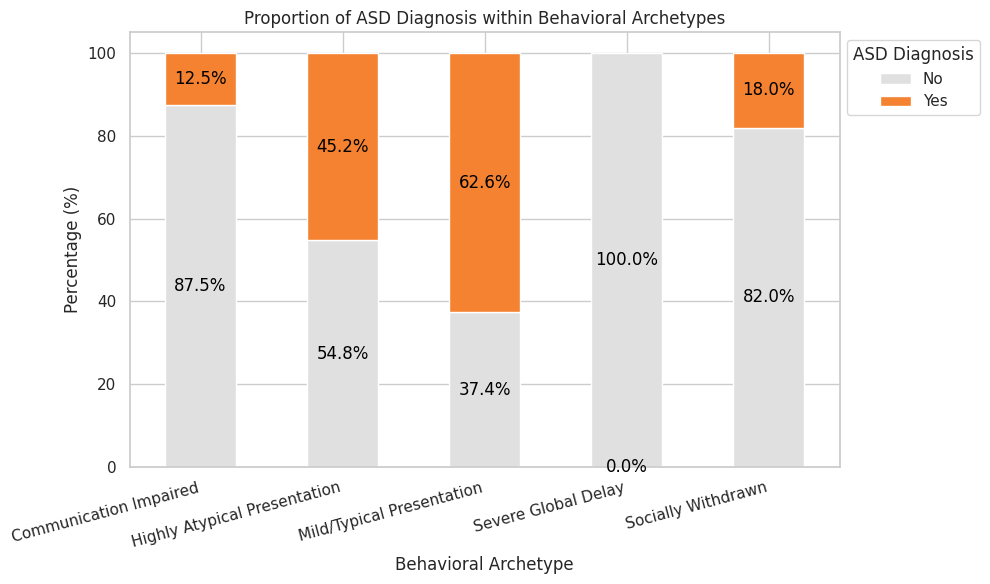

In [ ]:
# Capitalized 'Class' to match your standardized DataFrame
if 'Behavioral_Archetype' in df.columns and 'Class' in df.columns:

    # Calculate the cross-tabulation percentages
    crosstab_arch = pd.crosstab(df['Behavioral_Archetype'], df['Class'], normalize='index') * 100

    # Create the plot and assign it to 'ax'
    ax = crosstab_arch.plot(kind='bar', stacked=True, color=['#e0e0e0', '#F58231'], figsize=(10, 6))

    # --- NEW CODE: Add centered percentage labels to the stacked bars ---
    for container in ax.containers:
        # fmt='%.1f%%' adds the percentage sign and rounds to 1 decimal place
        ax.bar_label(container, fmt='%.1f%%', label_type='center', color='black')

    plt.title('Proportion of ASD Diagnosis within Behavioral Archetypes')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Behavioral Archetype')

    # Keeps your x-axis labels from overlapping if the archetype names are long
    plt.xticks(rotation=15, ha='right')

    plt.legend(title='ASD Diagnosis', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig('archetype_stacked.png', dpi=300)
    plt.show() # Added to ensure the plot renders on your screen!

else:
    # Diagnostic print statement just in case
    print("ERROR: Could not find 'Behavioral_Archetype' or 'Class' in the dataset.")
    print("Current columns:", df.columns.tolist())

### Cross-Tabulation Sanity Checks

In [ ]:
# 1. Check the overall distribution of our new Archetypes
print("--- Overall Distribution of Behavioral Archetypes ---")
print(df['Behavioral_Archetype'].value_counts(normalize=True) * 100)
print("\n")

# 2. Check how these Archetypes align with the actual ASD Diagnosis ('Class')
print("--- Archetypes vs. Final ASD Diagnosis ---")
archetype_crosstab = pd.crosstab(
    index=df['Behavioral_Archetype'],
    columns=df['Class'],
    normalize='index' # Shows the percentage of diagnosis WITHIN each archetype
) * 100

# Round to 2 decimal places for a clean, professional output
print(archetype_crosstab.round(2))

--- Overall Distribution of Behavioral Archetypes ---
Behavioral_Archetype
Mild/Typical Presentation       35.144033
Severe Global Delay             26.189300
Communication Impaired          18.008230
Socially Withdrawn              14.320988
Highly Atypical Presentation     6.337449
Name: proportion, dtype: float64


--- Archetypes vs. Final ASD Diagnosis ---
Class                             No    Yes
Behavioral_Archetype                       
Communication Impaired         87.48  12.52
Highly Atypical Presentation   54.81  45.19
Mild/Typical Presentation      37.42  62.58
Severe Global Delay           100.00   0.00
Socially Withdrawn             81.95  18.05


## Proxy Metrics & Final Dataset Lock
Objective: Engineer specific markers that tell a story about healthcare timelines and patient coping mechanisms.

### Late Diagnosis Flag

In [ ]:
df['Late_Diagnosis_Flag'] = ((df['Age'] >= 18) & (df['Class'] == 1)).astype(int)

print("Distribution of 'Late_Diagnosis_Flag':")
display(df['Late_Diagnosis_Flag'].value_counts())

print("First few rows with 'Late_Diagnosis_Flag':")
display(df.head())

Distribution of 'Late_Diagnosis_Flag':


,count
Late_Diagnosis_Flag,
0,6075


First few rows with 'Late_Diagnosis_Flag':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Age_Group,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Total_Atypical_Trait_Burden,Empathy_Imagination_Profile,Behavioral_Archetype,Late_Diagnosis_Flag
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,Adolescent,0,Neither,2,2,1,4,Other,Communication Impaired,0
2,0,1,1,1,0,1,1,0,1,0,...,Adolescent,0,Neither,2,0,2,3,Other,Mild/Typical Presentation,0
3,1,1,1,0,1,1,1,1,1,1,...,Adolescent,0,Family ASD Only,3,1,1,2,Other,Mild/Typical Presentation,0
4,1,1,1,1,1,1,1,1,0,0,...,Adolescent,0,Neither,3,1,0,1,Other,Mild/Typical Presentation,0
5,1,1,1,1,1,1,1,1,1,1,...,Adolescent,0,Neither,3,0,1,1,Other,Mild/Typical Presentation,0


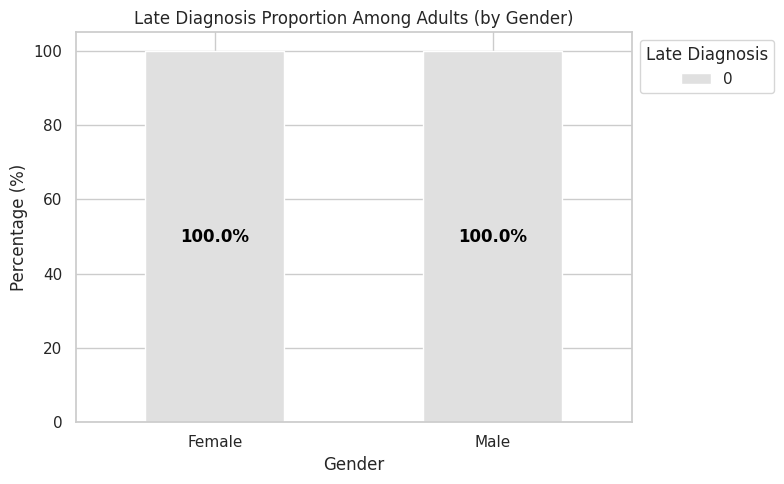

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Fixed casing for Sex and Age
if 'Late_Diagnosis_Flag' in df.columns and 'Sex' in df.columns and 'Age' in df.columns:
    adults = df[df['Age'] >= 18]

    # Calculate crosstab
    crosstab_late = pd.crosstab(adults['Sex'], adults['Late_Diagnosis_Flag'], normalize='index') * 100

    # Create plot and capture 'ax'
    ax = crosstab_late.plot(kind='bar', stacked=True, color=['#e0e0e0', '#F58231'], figsize=(8, 5))

    # --- NEW CODE: Add centered percentage labels ---
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center', color='black', weight='bold')

    plt.title('Late Diagnosis Proportion Among Adults (by Gender)')
    plt.ylabel('Percentage (%)')
    plt.xlabel('Gender')
    plt.xticks(rotation=0)
    plt.legend(title='Late Diagnosis', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig('late_diagnosis_stacked.png', dpi=300)

    plt.show() # Replaced plt.close() so you can actually see it!

else:
    print("ERROR: Could not find 'Late_Diagnosis_Flag', 'Sex', or 'Age' in the dataset.")

### Masking Proxy Flag

**Masking** (camouflaging autistic traits) is a critical topic in modern clinical data. Identifying patients who believe their communication is typical—despite severe deficits in other areas—adds immense depth to exploratory analysis

In [ ]:
df['Masking_Proxy_Flag'] = ((df['Class'] == 1) & (df['A8'] == 1)).astype(int)

print("Distribution of 'Masking_Proxy_Flag':")
display(df['Masking_Proxy_Flag'].value_counts())

print("First few rows with 'Masking_Proxy_Flag':")
display(df.head())

Distribution of 'Masking_Proxy_Flag':


,count
Masking_Proxy_Flag,
0,6075


First few rows with 'Masking_Proxy_Flag':


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,High_Risk_Background,Risk_Overlap,Social_Interaction_Score,Communication_Deficit_Score,Behavioral_Atypicality_Score,Total_Atypical_Trait_Burden,Empathy_Imagination_Profile,Behavioral_Archetype,Late_Diagnosis_Flag,Masking_Proxy_Flag
Case_Number,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,1,1,0,0,...,0,Neither,2,2,1,4,Other,Communication Impaired,0,0
2,0,1,1,1,0,1,1,0,1,0,...,0,Neither,2,0,2,3,Other,Mild/Typical Presentation,0,0
3,1,1,1,0,1,1,1,1,1,1,...,0,Family ASD Only,3,1,1,2,Other,Mild/Typical Presentation,0,0
4,1,1,1,1,1,1,1,1,0,0,...,0,Neither,3,1,0,1,Other,Mild/Typical Presentation,0,0
5,1,1,1,1,1,1,1,1,1,1,...,0,Neither,3,0,1,1,Other,Mild/Typical Presentation,0,0


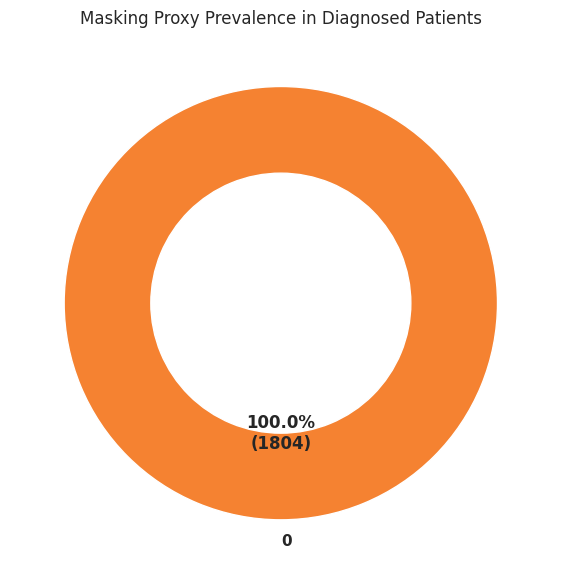

In [ ]:
plt.figure(figsize=(6, 6))

# Fixed casing for Class and 'Yes'
if 'Masking_Proxy_Flag' in df.columns and 'Class' in df.columns:
    diagnosed = df[df['Class'] == 'Yes']
    masking_counts = diagnosed['Masking_Proxy_Flag'].value_counts()

    # --- NEW CODE: Custom function to show both Percentage AND Raw Count ---
    def make_autopct(values):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            # Formats the text as "Percentage%\n(Count)"
            return f'{pct:.1f}%\n({val})'
        return my_autopct

    # Apply our custom autopct function
    plt.pie(masking_counts, labels=masking_counts.index,
            autopct=make_autopct(masking_counts),
            startangle=90, colors=['#F58231', '#FCE6C9'],
            wedgeprops=dict(width=0.4), textprops={'weight': 'bold'})

    plt.title('Masking Proxy Prevalence in Diagnosed Patients')
    plt.tight_layout()
    plt.savefig('masking_pie.png', dpi=300)

    plt.show()

else:
    print("ERROR: Could not find 'Masking_Proxy_Flag' or 'Class' in the dataset.")

## Saving the updated dataframe to a new csv file

In [ ]:
#df.to_csv('Autism_Screening_Data_Processed.csv', index=False)
#print("DataFrame saved to 'Autism_Screening_Data_Processed.csv'")